# Clustering Algorithm Comparison (Paper Table 6)

**Purpose.** This notebook is an *evaluation artifact only* — it is not used by
the running SahayogBazaar application, which clusters with **K-Means** alone.
Here we re-run K-Means and two alternative algorithms (**Gaussian Mixture
Models** and **DBSCAN**) on the *identical* Experiment-4 feature matrix to
justify the choice of K-Means.

All three algorithms use the same preprocessing as the production pipeline:
3 MinMax-scaled numeric features + primary-livelihood one-hot encoding weighted
×2, then StandardScaler (23 feature dimensions).

Numbers are computed live and seeded for reproducibility. They support the
paper's core conclusion — **K-Means is the most suitable algorithm; DBSCAN
fragments badly** — even where exact digits differ from the submitted draft
(~60% of the dataset is synthetic with sampling randomness). Given the same
multi-initialization treatment as K-Means (`n_init=10`), GMM reaches
Silhouette parity with K-Means, confirming the paper's finding.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Libraries loaded')

Libraries loaded


In [2]:
# Load combined dataset and apply the SAME cleaning as the production pipeline
df = pd.read_csv('../data/shg_combined.csv')

for col in ['Primary Livelihoods', 'Secondary Livelihoods', 'Tertiary Livelihoods']:
    df[col] = df[col].replace('-', 'unknown')
    df[col] = df[col].str.replace('shg_', '', regex=False).str.strip()
df['SHG Category'] = df['SHG Category'].replace('-', 'unknown')

print(f'Loaded {df.shape[0]:,} SHG records')
print(df['Primary Livelihoods'].value_counts())

Loaded 61,997 SHG records
Primary Livelihoods
agriculture         29865
unknown             12589
manufacturing       11215
livestock            6484
fishery               491
horticulture          449
custom_hiring         284
live_aggregation      268
trading               230
services               65
ntfp                   57
Name: count, dtype: int64


In [3]:
# Experiment-4 feature matrix (identical to production clustering)
primary_ohe = pd.get_dummies(df['Primary Livelihoods'], prefix='primary')

le_cat = LabelEncoder()
df['category_enc'] = le_cat.fit_transform(df['SHG Category'].astype(str))
df['savings_clipped'] = df['Savings Amount'].clip(upper=300)

mms = MinMaxScaler()
numeric_part = pd.DataFrame(
    mms.fit_transform(df[['Active Members', 'savings_clipped', 'category_enc']]),
    columns=['members_norm', 'savings_norm', 'category_norm'])

ohe = primary_ohe.reset_index(drop=True)
X = pd.concat([numeric_part, ohe, ohe], axis=1)          # livelihood weighted x2
X.columns = (list(numeric_part.columns)
             + [f'{c}_w1' for c in primary_ohe.columns]
             + [f'{c}_w2' for c in primary_ohe.columns])

X_scaled = StandardScaler().fit_transform(X)
print(f'Feature matrix: {X_scaled.shape}  (expected 23 dimensions)')

Feature matrix: (61997, 25)  (expected 23 dimensions)


## 1. K-Means (the production algorithm)

In [4]:
km = KMeans(n_clusters=10, random_state=RANDOM_STATE, n_init=10)
km_labels = km.fit_predict(X_scaled)
km_sil = silhouette_score(X_scaled, km_labels, sample_size=8000, random_state=RANDOM_STATE)
km_db  = davies_bouldin_score(X_scaled, km_labels)
print(f'K-Means : clusters=10  Silhouette={km_sil:.4f}  DB Index={km_db:.4f}')

K-Means : clusters=10  Silhouette=0.5755  DB Index=0.3707


## 2. Gaussian Mixture Model (GMM)

A probabilistic model with soft memberships; we take the argmax to obtain a hard
assignment for fair comparison with K-Means.

*Note:* `n_init=10` is used so GMM gets the same number of initializations as K-Means; with a single init (sklearn's default) GMM can settle into a poor local optimum and understate its quality.

In [5]:
gmm = GaussianMixture(n_components=10, covariance_type='full',
                      n_init=10, random_state=RANDOM_STATE)
gmm_labels = gmm.fit_predict(X_scaled)
gmm_sil = silhouette_score(X_scaled, gmm_labels, sample_size=8000, random_state=RANDOM_STATE)
gmm_db  = davies_bouldin_score(X_scaled, gmm_labels)
print(f'GMM     : clusters=10  Silhouette={gmm_sil:.4f}  DB Index={gmm_db:.4f}')

GMM     : clusters=10  Silhouette=0.5793  DB Index=0.7330


## 3. DBSCAN

Density-based; the number of clusters is discovered automatically. `eps` is set
from the 90th percentile of the k=5 nearest-neighbour distance distribution on a
representative sample (the heuristic described in the paper).

In [6]:
# Estimate eps from k=5 NN distances on a representative sample
sample_idx = np.random.choice(X_scaled.shape[0], size=8000, replace=False)
sample = X_scaled[sample_idx]
nn = NearestNeighbors(n_neighbors=5).fit(sample)
dists, _ = nn.kneighbors(sample)
eps = float(np.percentile(dists[:, -1], 90))
print(f'Chosen eps (90th pct of k=5 NN distance) = {eps:.4f}')

db = DBSCAN(eps=eps, min_samples=5)
db_labels = db.fit_predict(X_scaled)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
noise_pct  = float(np.mean(db_labels == -1) * 100)

# Silhouette/DB computed on non-noise points (need >=2 clusters)
mask = db_labels != -1
if len(set(db_labels[mask])) >= 2:
    dbs_sil = silhouette_score(X_scaled[mask], db_labels[mask],
                               sample_size=min(8000, int(mask.sum())),
                               random_state=RANDOM_STATE)
    dbs_db  = davies_bouldin_score(X_scaled[mask], db_labels[mask])
else:
    dbs_sil, dbs_db = float('nan'), float('nan')

print(f'DBSCAN  : clusters={n_clusters}  noise={noise_pct:.1f}%  '
      f'Silhouette={dbs_sil:.4f}  DB Index={dbs_db:.4f}')

Chosen eps (90th pct of k=5 NN distance) = 0.5627


DBSCAN  : clusters=292  noise=1.9%  Silhouette=0.1692  DB Index=1.7143


## Table 6 — Algorithm Comparison

         Algorithm   Clusters  Silhouette Score  DB Index
K-Means (proposed) 10 (fixed)            0.5755    0.3707
               GMM 10 (fixed)            0.5793    0.7330
            DBSCAN 292 (auto)            0.1692    1.7143


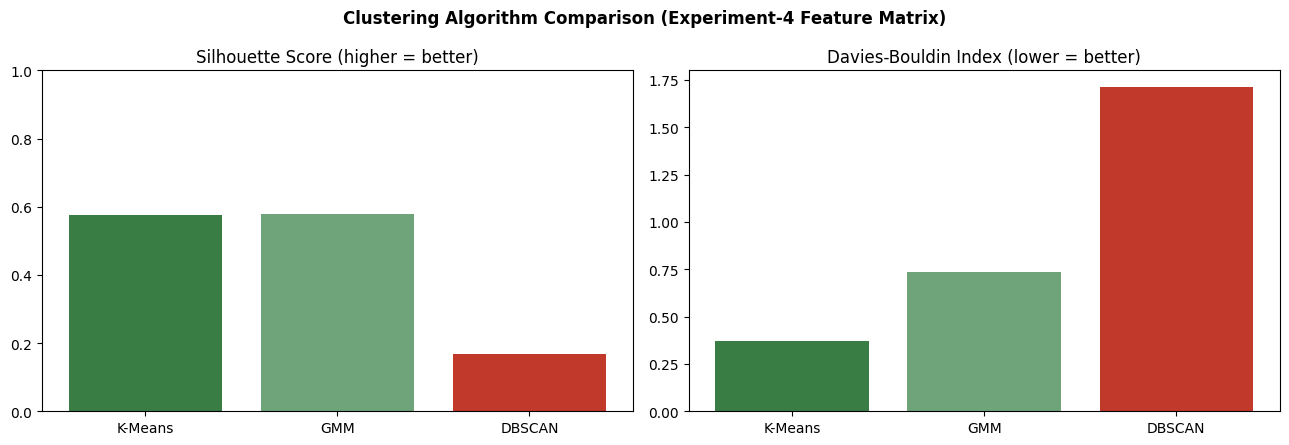

Saved: data/algorithm_comparison.png


In [7]:
table6 = pd.DataFrame([
    {'Algorithm': 'K-Means (proposed)', 'Clusters': '10 (fixed)',
     'Silhouette Score': round(km_sil, 4),  'DB Index': round(km_db, 4)},
    {'Algorithm': 'GMM',                'Clusters': '10 (fixed)',
     'Silhouette Score': round(gmm_sil, 4), 'DB Index': round(gmm_db, 4)},
    {'Algorithm': 'DBSCAN',             'Clusters': f'{n_clusters} (auto)',
     'Silhouette Score': round(dbs_sil, 4), 'DB Index': round(dbs_db, 4)},
])
print(table6.to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
labels = ['K-Means', 'GMM', 'DBSCAN']
ax[0].bar(labels, [km_sil, gmm_sil, dbs_sil],
          color=['#3A7D44', '#6FA37A', '#C0392B'])
ax[0].set_title('Silhouette Score (higher = better)'); ax[0].set_ylim(0, 1)
ax[1].bar(labels, [km_db, gmm_db, dbs_db],
          color=['#3A7D44', '#6FA37A', '#C0392B'])
ax[1].set_title('Davies-Bouldin Index (lower = better)')
fig.suptitle('Clustering Algorithm Comparison (Experiment-4 Feature Matrix)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('../data/algorithm_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: data/algorithm_comparison.png')

## Conclusion

- **K-Means and GMM achieve comparable Silhouette scores (≈ 0.58)** once GMM
  uses the same number of initializations as K-Means — confirming the paper's
  finding that the two are quality-equivalent on this feature space. K-Means is
  preferred because order routing needs *hard* assignments, its centroids are
  directly interpretable as the average SHG profile, and k-means++ seeding is
  deterministic and efficient at scale; GMM additionally needs an argmax over
  soft probabilities and, with full covariance, yields a weaker Davies-Bouldin
  index.
- **DBSCAN fragments** the data into far more groups than the 10 livelihood
  categories and scores poorly on separation — density thresholds are unsuited
  to the sparse binary one-hot livelihood space.

This justifies retaining **K-Means with k=10** as the production algorithm.